In [1]:
#import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings
warnings.filterwarnings("ignore")

In [4]:
#read in raw data and make stationary
cpc = pd.read_csv('search_cpc.csv', parse_dates=['date'], index_col='date')
cpc_diff = cpc.diff()
cpc_diff = cpc_diff.dropna()

# Question 1

Plot the ACF and PACF of cpc_diff. Based on the plots, can the model order be deduced? If yes, what is the model order?

# Question 2

Write a for loop to loop over orders between 0 and 3 for p and q. Within the loop, try to fit an ARMA(p,q) and create an exception to print instances where the model fitting procedure fails. What is the model order for the best predictive model? 

# Question 3

Fit a model based off the best predictive model from Question 2 and create the four diagnostic plots. Which of the four plots indicate that there's room for model improvement?

# Question 4

We know from the augmented Dickey-Fuller test in Part 1, as well as the seasonal decomposition below that our time series has a trend and is non-stationary. Subtract a 365 step rolling mean from the time series and assign to a variable named cpc_2. Then plot the ACF with a time lag of 30 steps and show the plot. What is the time period of the seasonal component of this data?

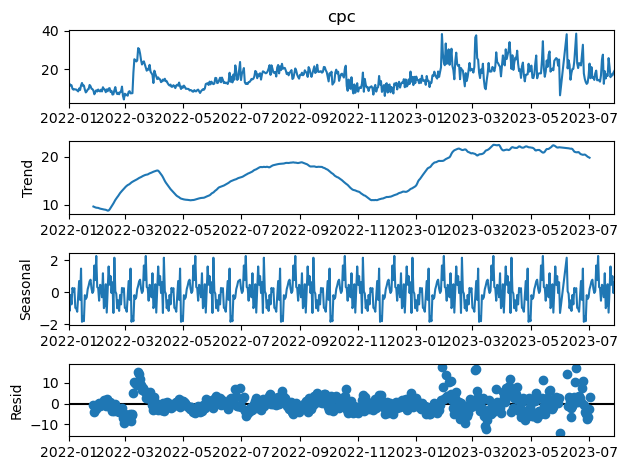

In [21]:
cpc = pd.read_csv('search_cpc.csv', parse_dates=['date'], index_col='date')

decomp = seasonal_decompose(cpc['cpc'], period=52)
decomp.plot()
plt.show()

# Question 5

Take the first order and seasonal difference from cpc and drop NAs and name your variable cpc_diff_season. Then plot the ACF and PACF up to 11 lags and interpret the non-seasonal model order from the plots. Then plot the seasonal ACF and PACF plots for the first 5 seasonal lags.

The guideline for interpreting model order is in the cell below, and can be used for both non-seasonal and seasonal ACF and PACF plots. 

What model is most likely for this data?

Hints:
1. You can chain the diff() function together to take the first order and seasonal difference in one line of code
2. The seasonal time lag is 7 time steps
3. Make sure to pass in time lags as a list for the seasonal ACF and PACF plots
4. Feel free to use multiple cells for this question

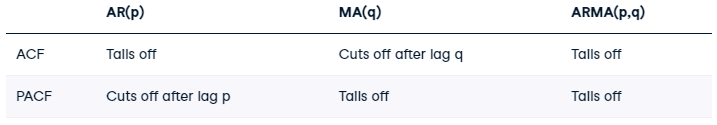

BONUS - after you have your answers above update the SARIMAX object with the correct model order values and then run the next two cells

In [25]:
#create model object and fit the model
model = SARIMAX(cpc, order=(p,d,q), seasonal_order=(P,D,Q,s))
results = model.fit()

#create forecast object for 91 steps into the future
forecast_object = results.get_forecast(steps=91)

#extract prediction mean
mean = forecast_object.predicted_mean

#extract the confidence intervals
conf_int = forecast_object.conf_int()

# extract the forecast dates
dates = mean.index

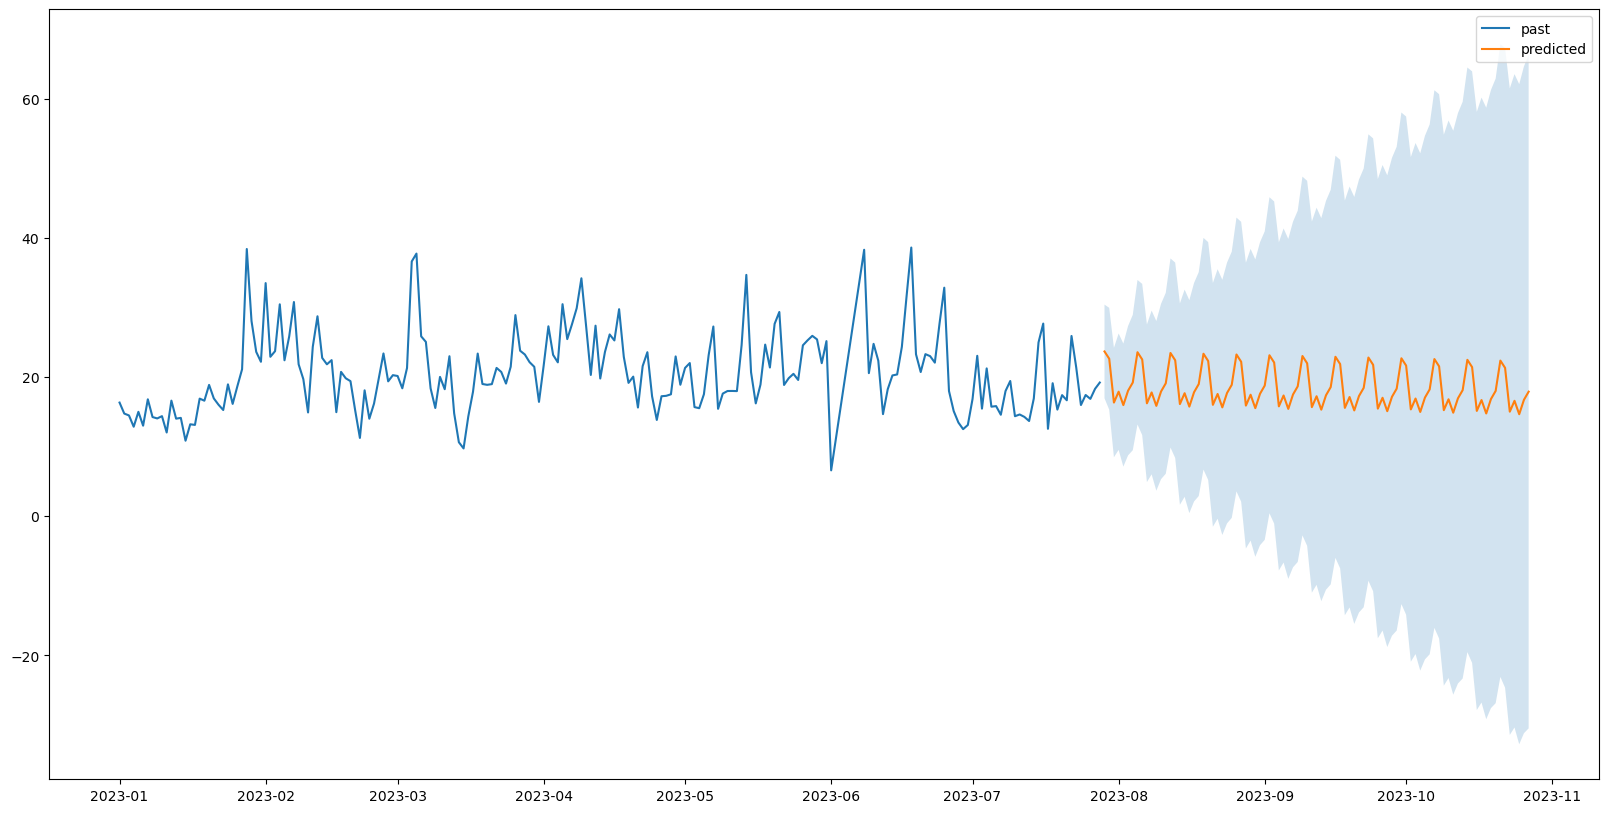

In [26]:
import matplotlib.dates as mdates

forecast_dates = pd.date_range(start=cpc.index[-1] + pd.Timedelta(days=1), periods=91, freq='D')
forecast_series = pd.Series(mean.values, index=forecast_dates)

plt.figure(figsize=(20,10))

#plot past paid search CPCs
cpc_short = cpc["2023-01-01": "2023-07-28"]
plt.plot(cpc_short.index, cpc_short, label='past')

#plot the prediction means as line
plt.plot(forecast_series.index, forecast_series, label='predicted')

#shade between the confidence intervals
plt.fill_between(forecast_series.index, conf_int.iloc[:,0], conf_int.iloc[:,1], alpha=0.2)

#plot legend and show figure
plt.legend()
plt.show()